# Making TauREx3 differentiable: evidence for the decision

This notebook drives the prototype in `diffproto.py` (same folder), a miniature of the
TauREx3 transit forward model, and is meant to be worked through together to decide **how to
proceed**. It answers three questions in order, and every claim is backed by a number
measured in this notebook:

1. **Can** the forward model be differentiated? (section 3)
2. **Is it worth it?** (sections 2, 4, 6, 8, 9)
3. **JAX or PyTorch, and what has to change?** (sections 9, 10, 11)

Read it as follows: sections 1-7 are the measurements, section 8 is the payoff verdict,
sections 9-11 are the framework decision and the migration inventory, and section 12 is a
proposed agenda with success criteria for the next few experiments.

The prototype reproduces every obstacle the report lists in `DIFFERENTIABILITY.md`, in the
place the real code has it: `searchsorted` opacity lookup, the per-layer in-place `+=` loop,
the `if tau[layer].min() > 10: continue` early-out, the in-place `np.exp(-tau, out=tau)`,
and `scipy.special.expn` in the Guillot profile. It does *not* contain k-tables, CIA, clouds
or 100 layers, so it validates the approach, not the port.

In [1]:
import pathlib
import sys
import time

import numpy as np

here = pathlib.Path.cwd()
proto_dir = (
    here
    if (here / "diffproto.py").exists()
    else pathlib.Path("examples/differentiability").resolve()
)
sys.path.insert(0, str(proto_dir))

import diffproto as proto  # noqa: E402

print(proto.device_report())
print("layers                  :", proto.NLAYERS, "layers x", proto.NWN, "wavenumbers")
print("fitting parameters      :", ", ".join(proto.THETA_NAMES))
print("n_params                :", proto.THETA0.size, "(gases + 3 structural)")
print("theta0                  :", proto.THETA0)
print("theta of the 'observed' :", proto.THETA_DATA)

torch cuda=True | jax backend=gpu devices=[CudaDevice(id=0)]
layers                  : 40 layers x 300 wavenumbers
fitting parameters      : log10_X1, T_irr, alpha, kappa_ir
n_params                : 4 (gases + 3 structural)
theta0                  : [-3.0e+00  1.2e+03  5.0e-01  1.0e-03]
theta of the 'observed' : [-2.95e+00  1.23e+03  5.20e-01  1.10e-03]


## 1. The forward model

```
theta = [log10_X_1 .. log10_X_K, T_irr, alpha, kappa_ir]
   |  Guillot2010 profile            <- scipy.special.expn(2, .)
   v  T(P)
bilinear (T, log10 P) opacity interpolation   <- searchsorted indices + linear weights
   v  sigma_gas[gas, layer, wn]
sigma_mix[layer, wn] = sum_gas X_gas * sigma_gas[gas, layer, wn]
   v
tau[layer, wn] = sum_k path[layer, k] * n[k] * sigma_mix[k, wn]   <- per-layer loop
   v
transit depth = (R_p^2 + sum_layers (R_p + z) (1 - e^-tau) dz * 2) / R_s^2
```

Every step is `exp`, `log`, `sqrt` and polynomial algebra, so the mathematics is already
differentiable; the obstacles are structural. Adding a gas adds one parameter, which is what
makes the parameter-count scaling experiment in section 4 possible.

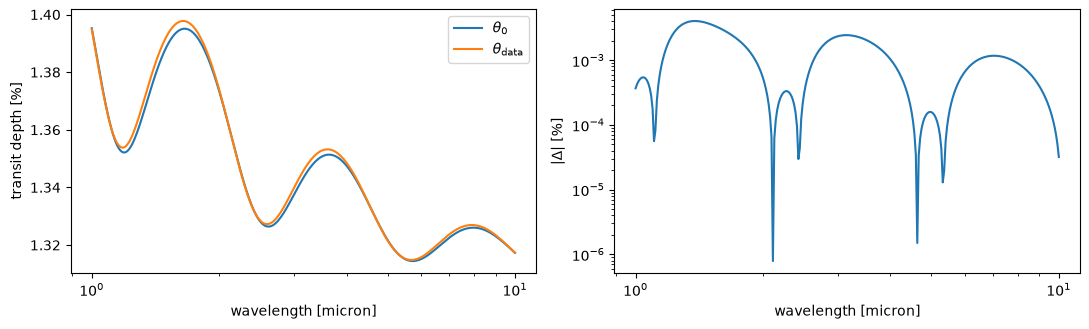

transit depth: 1.314% .. 1.395%


In [2]:
import matplotlib.pyplot as plt

wavelength = 1e6 * proto.WNG_GRID  # m -> micron
base = proto.forward_np(proto.THETA0)
shifted = proto.forward_np(proto.THETA_DATA)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(wavelength, 100 * base, label=r"$\theta_0$")
axes[0].plot(wavelength, 100 * shifted, label=r"$\theta_{\rm data}$")
axes[0].set_xscale("log")
axes[0].set_xlabel("wavelength [micron]")
axes[0].set_ylabel("transit depth [%]")
axes[0].legend()

axes[1].loglog(wavelength, 100 * np.abs(shifted - base))
axes[1].set_xlabel("wavelength [micron]")
axes[1].set_ylabel(r"$|\Delta|$ [%]")
fig.tight_layout()
plt.show()

print(f"transit depth: {100 * base.min():.3f}% .. {100 * base.max():.3f}%")

## 2. What does one gradient cost?

Everything that follows comes from this accounting. For $n$ parameters:

| method | model evaluations per gradient |
| --- | --- |
| central finite differences | $2n$ forward passes |
| reverse-mode autodiff | 1 forward + 1 backward |

A backward pass costs roughly one forward pass, so autodiff is about **two
forward-equivalents regardless of $n$**, while finite differences are $2n$. At $n = 4$ that
predicts a factor of ~4; at $n = 20$ it predicts ~20.

The measurement below runs *both* on the same GPU, so the comparison is like for like.

device            : cuda
n_params          : 4
one forward       :   1.973 ms
autograd gradient :   5.472 ms   (1 forward + 1 backward)
finite differences:  16.755 ms   (8 forward passes)
autograd speed-up :    3.06x


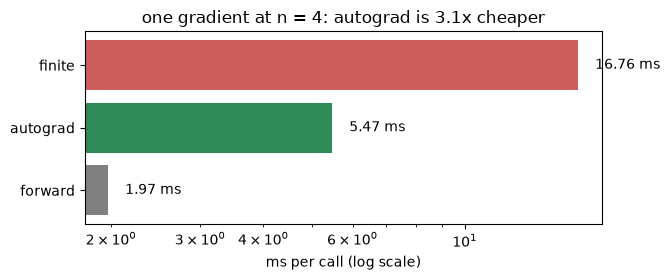

In [3]:
cost = proto.gradient_cost(1, repeats=10)
print(f"device            : {cost['device']}")
print(f"n_params          : {cost['n_params']}")
print(f"one forward       : {cost['forward_ms']:7.3f} ms")
print(f"autograd gradient : {cost['autograd_ms']:7.3f} ms   (1 forward + 1 backward)")
print(
    f"finite differences: {cost['finite_difference_ms']:7.3f} ms"
    f"   ({cost['fd_evaluations']} forward passes)"
)
print(f"autograd speed-up : {cost['speedup']:7.2f}x")

labels = ["forward", "autograd", "finite"]
values = [cost["forward_ms"], cost["autograd_ms"], cost["finite_difference_ms"]]
colors = ["grey", "seagreen", "indianred"]

fig, ax = plt.subplots(figsize=(6.8, 2.9))
ax.barh(labels, values, color=colors)
for row, value in enumerate(values):
    ax.text(value * 1.08, row, f"{value:.2f} ms", va="center")
ax.set_xscale("log")
ax.set_xlabel("ms per call (log scale)")
ax.set_title(
    f"one gradient at n = {cost['n_params']}: autograd is {cost['speedup']:.1f}x cheaper"
)
fig.tight_layout()
plt.show()

## 3. Do the autodiff gradients agree with finite differences?

This is the **correctness** check, and the one place where finite differences are the
*reference* rather than the competitor. Everything the prototype does (detached
`searchsorted` indices, a custom `E_2` rule, no in-place `exp`) is validated here.

Note what it does *not* tell you: nothing in this cell is faster. Correctness and payoff are
different questions.

In [4]:
import torch

fd = proto.finite_difference_grad(proto.chisq_np, proto.THETA0)

theta_t = torch.tensor(proto.THETA0, dtype=torch.float64, requires_grad=True)
proto.chisq_torch(theta_t).backward()
torch_grad = theta_t.grad.cpu().numpy()

import jax
import jax.numpy as jnp

proto._jax()
arrays = proto._jax_arrays()
jax_grad = np.asarray(
    jax.jit(jax.grad(lambda t: proto.chisq_jax(t, arrays=arrays)))(
        jnp.asarray(proto.THETA0)
    )
)

print(f"{'param':>10} {'finite diff':>16} {'torch':>16} {'jax':>16}")
for i, name in enumerate(proto.THETA_NAMES):
    print(f"{name:>10} {fd[i]:16.9e} {torch_grad[i]:16.9e} {jax_grad[i]:16.9e}")
print()
print(f"max |torch - FD| / |FD| : {np.max(np.abs(torch_grad - fd) / np.abs(fd)):.2e}")
print(f"max |jax   - FD| / |FD| : {np.max(np.abs(jax_grad - fd) / np.abs(fd)):.2e}")
print(f"max |jax - torch|       : {np.max(np.abs(jax_grad - torch_grad)):.2e}")

     param      finite diff            torch              jax
  log10_X1 -6.150720498e+00 -6.150720500e+00 -6.150720500e+00
     T_irr  3.860661201e-03  3.860661201e-03  3.860661201e-03
     alpha -7.697803251e-01 -7.697803242e-01 -7.697803242e-01
  kappa_ir  3.837713430e+02  3.837717925e+02  3.837717925e+02

max |torch - FD| / |FD| : 1.17e-06
max |jax   - FD| / |FD| : 1.17e-06
max |jax - torch|       : 4.40e-11


## 4. The payoff is the slope, not the constant

Section 2 showed ~3x at $n = 4$. That alone would not justify a rewrite: finite differences
are ten lines of code and need no differentiable model at all.

The point is what happens as $n$ grows. Adding gases adds parameters one at a time, so the
parameter count can be varied honestly instead of extrapolated. Watch the autograd cost stay
flat while the finite-difference cost climbs.

 n_params   forward  autograd  finite diff   FD/AD
        4     1.900     5.065       17.464    3.45
        5     1.862     5.171       21.323    4.12
        6     1.814     5.080       26.549    5.23
        7     1.824     5.013       31.222    6.23
        9     1.885     5.095       39.659    7.78
       11     1.819     5.097       48.336    9.48


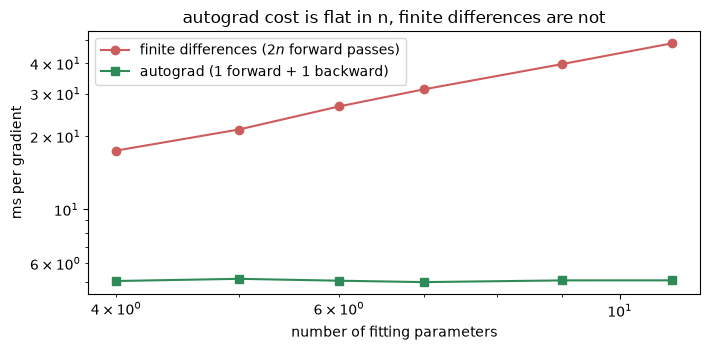

log-log slope of the finite-difference cost: 1.02  (1.0 = linear in n)
extrapolated to n = 20: FD ~ 79 ms vs autograd ~ 5.1 ms per gradient


In [5]:
rows = proto.scaling_report(repeats=20)
n_params = np.array([row["n_params"] for row in rows])
fd_ms = np.array([row["finite_difference_ms"] for row in rows])
ad_ms = np.array([row["autograd_ms"] for row in rows])

print(f"{'n_params':>9} {'forward':>9} {'autograd':>9} {'finite diff':>12} {'FD/AD':>7}")
for row in rows:
    print(
        f"{row['n_params']:>9} {row['forward_ms']:>9.3f} {row['autograd_ms']:>9.3f}"
        f" {row['finite_difference_ms']:>12.3f} {row['speedup']:>7.2f}"
    )

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.loglog(
    n_params,
    fd_ms,
    "o-",
    color="indianred",
    label=r"finite differences ($2n$ forward passes)",
)
ax.loglog(
    n_params,
    ad_ms,
    "s-",
    color="seagreen",
    label="autograd (1 forward + 1 backward)",
)
ax.set_xlabel("number of fitting parameters")
ax.set_ylabel("ms per gradient")
ax.set_title("autograd cost is flat in n, finite differences are not")
ax.legend()
fig.tight_layout()
plt.show()

slope = np.polyfit(np.log(n_params), np.log(fd_ms), 1)[0]
print(f"log-log slope of the finite-difference cost: {slope:.2f}  (1.0 = linear in n)")
print(
    f"extrapolated to n = 20: FD ~ {cost['forward_ms'] * 2 * 20:.0f} ms"
    f" vs autograd ~ {ad_ms.mean():.1f} ms per gradient"
)

## 5. Jacobians and the Fisher matrix: mode choice matters

A MAP fit needs the gradient of a *scalar*, which is what reverse mode is built for. Error
bars need the whole Jacobian $J = \partial S/\partial\theta$, and there the mode matters:

| quantity | finite differences | forward mode | reverse mode |
| --- | --- | --- | --- |
| gradient of a scalar loss | $2n$ forwards | -- | 1 forward + 1 backward |
| Jacobian (n x m) | $2n$ forwards | $n$ JVPs | $m$ VJPs |
| Hessian / Fisher (n x n) | $\sim n^2/2$ forwards | $n$ JVPs | $n$ VJPs |

This model has $n = 4$ inputs and $m = 300$ outputs, so the *counts* favour forward mode
(4 JVPs) and punish reverse mode (300 VJPs). The wall-clock times at this size are
comparable because overhead dominates; the counts are what transfer to a real retrieval with
$m \sim 10^4$ and $n \sim 20$.

Two practical details fall out of the measurement:

* the first JAX call pays ~0.6 s of compilation per shape, the ahead-of-time contract you
  accept with `jit`;
* `jax.jacfwd` works out of the box, but `torch.func.jacfwd` needs a *vmappable* forward, and a
  host-side scipy `E_2` is not one, so only `jacrev` works there. Reaching for scipy inside the
  primal costs composability (section 9 measures the batching consequence).

n_params = 4, n_wavenumbers = 300
forward mode, jax.jacfwd (4 JVPs)          :    1.40 ms
(first call, incl. compilation)                    : 1196.29 ms
reverse mode, torch.func.jacrev (300 VJPs) :   20.49 ms
finite differences (8 forwards)          :   15.79 ms

singular values of J / sigma : [1.3156e+03 4.9060e+00 1.3791e-03 1.1562e-08]
condition number            : 1.138e+11
least-constrained direction : {'log10_X1': -0.022, 'T_irr': -0.023, 'alpha': 0.053, 'kappa_ir': -0.038}

     param        value  Laplace 1-sigma   relative
  log10_X1           -3           0.2045     6.82%
     T_irr         1200            4.253     0.35%
     alpha          0.5            725.1 145014.76%
  kappa_ir        0.001            1.454 145416.56%


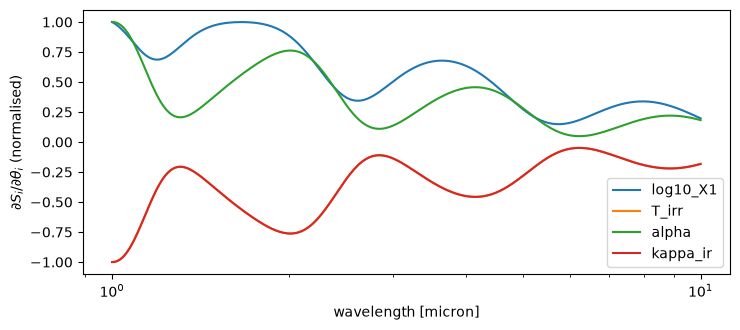

In [6]:
from torch.func import jacrev

device = cost["device"]
arrays_t = proto._torch_arrays(device)
theta_dev = torch.tensor(proto.THETA0, dtype=torch.float64, device=device)
forward_dev = lambda t: proto.forward_torch(t, arrays=arrays_t)


def timed(func, repeats=5):
    # fastest wall-clock time in ms, syncing the GPU when present
    func()
    if device == "cuda":
        torch.cuda.synchronize()
    best = float("inf")
    for _ in range(repeats):
        start = time.perf_counter()
        func()
        if device == "cuda":
            torch.cuda.synchronize()
        best = min(best, time.perf_counter() - start)
    return best * 1e3


n_params = proto.THETA0.size
n_outputs = proto.WNG_GRID.size
jax_jacobian = jax.jit(jax.jacfwd(lambda t: proto.forward_jax(t, arrays=arrays)))
theta_j = jnp.asarray(proto.THETA0)

start = time.perf_counter()
jac = np.asarray(jax_jacobian(theta_j)).T  # (n_params, n_wavenumbers)
first_call_ms = (time.perf_counter() - start) * 1e3
forward_ms = timed(lambda: np.asarray(jax_jacobian(theta_j)))
reverse_ms = timed(lambda: jacrev(forward_dev)(theta_dev))
fd_ms = 2 * n_params * cost["forward_ms"]
print(f"n_params = {n_params}, n_wavenumbers = {n_outputs}")
print(f"forward mode, jax.jacfwd ({n_params} JVPs)          : {forward_ms:7.2f} ms")
print(f"(first call, incl. compilation)                    : {first_call_ms:7.2f} ms")
print(f"reverse mode, torch.func.jacrev ({n_outputs} VJPs) : {reverse_ms:7.2f} ms")
print(f"finite differences ({2 * n_params} forwards)          : {fd_ms:7.2f} ms")

normalised = jac / proto.ERR
_, singular_values, right_vectors = np.linalg.svd(normalised)
fisher = normalised @ normalised.T
covariance = np.linalg.pinv(fisher)
uncertainty = np.sqrt(np.diag(covariance))

print()
print("singular values of J / sigma :", np.array2string(singular_values, precision=4))
print(f"condition number            : {singular_values[0] / singular_values[-1]:.4g}")
print(
    "least-constrained direction :",
    {name: round(float(v), 3) for name, v in zip(proto.THETA_NAMES, right_vectors[-1])},
)
print()
print(f"{'param':>10} {'value':>12} {'Laplace 1-sigma':>16} {'relative':>10}")
for i, name in enumerate(proto.THETA_NAMES):
    print(
        f"{name:>10} {proto.THETA0[i]:12.4g} {uncertainty[i]:16.4g}"
        f" {uncertainty[i] / abs(proto.THETA0[i]):9.2%}"
    )

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, name in enumerate(proto.THETA_NAMES):
    ax.plot(wavelength, jac[i] / np.max(np.abs(jac[i])), label=name)
ax.set_xscale("log")
ax.set_xlabel("wavelength [micron]")
ax.set_ylabel(r"$\partial S_i / \partial \theta_i$ (normalised)")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Does it pay off for the fit itself?

Counting model evaluations is device-independent, so it is the honest way to compare a
gradient-based fit with a gradient-free one. L-BFGS gets a gradient per iteration;
Nelder-Mead (scipy) sees function values only.

At this model size the gradient method should win by roughly `2n = 8` on evaluations, plus
whatever the gradient-free search wastes wandering. Any further gain depends on the
optimiser, not on differentiability.

L-BFGS      :   28 gradients (~  56 forward passes)    137.0 ms  chi2 = 8.78e-07
Nelder-Mead :  667 evaluations                       919.0 ms  chi2 = 3.41e-11

     param        start       L-BFGS  Nelder-Mead   theta_data
  log10_X1         -3.1        -2.95        -2.95        -2.95
     T_irr         1050         1050         1176         1230
     alpha         0.35       0.3502       0.1691         0.52
  kappa_ir       0.0006     0.002897    0.0009995       0.0011


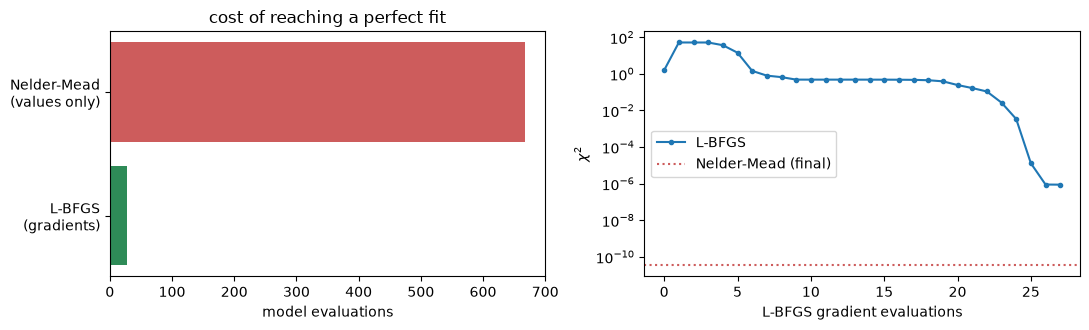

In [7]:
start = np.array([-3.10, 1050.0, 0.35, 6.0e-4])
fit = proto.optimizer_comparison(start)

print(
    f"L-BFGS      : {fit['lbfgs_evaluations']:4d} gradients"
    f" (~{fit['lbfgs_forward_equivalents']:4d} forward passes)"
    f"  {fit['lbfgs_seconds'] * 1e3:7.1f} ms  chi2 = {fit['lbfgs_chisq']:.3g}"
)
print(
    f"Nelder-Mead : {fit['gradient_free_evaluations']:4d} evaluations"
    f"{'':19s}  {fit['gradient_free_seconds'] * 1e3:7.1f} ms"
    f"  chi2 = {fit['gradient_free_chisq']:.3g}"
)
print()
print(f"{'param':>10} {'start':>12} {'L-BFGS':>12} {'Nelder-Mead':>12} {'theta_data':>12}")
for i, name in enumerate(proto.THETA_NAMES):
    print(
        f"{name:>10} {start[i]:12.4g} {fit['lbfgs_fit'][i]:12.4g}"
        f" {fit['gradient_free_fit'][i]:12.4g} {proto.THETA_DATA[i]:12.4g}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].barh(
    ["L-BFGS\n(gradients)", "Nelder-Mead\n(values only)"],
    [fit["lbfgs_evaluations"], fit["gradient_free_evaluations"]],
    color=["seagreen", "indianred"],
)
axes[0].set_xlabel("model evaluations")
axes[0].set_title("cost of reaching a perfect fit")

axes[1].semilogy(fit["lbfgs_history"], marker="o", ms=3, label="L-BFGS")
axes[1].axhline(
    fit["gradient_free_chisq"], ls=":", c="indianred", label="Nelder-Mead (final)"
)
axes[1].set_xlabel("L-BFGS gradient evaluations")
axes[1].set_ylabel(r"$\chi^2$")
axes[1].legend()
fig.tight_layout()
plt.show()

## 7. The one construct that genuinely breaks autodiff

`TransmissionModel.path_integral` contains

```python
if tau[layer].min() > 10:
    continue
```

The decision couples contributions: layer `l`'s accumulated depth decides whether the next
contribution is added at all. The function is **discontinuous** at the threshold, so no
derivative exists there, but autodiff silently returns the derivative of whichever branch it
happens to be on. Making a model differentiable does not make it smooth. This is why the
migration has to freeze that decision (or mask it) rather than port it literally.

autodiff d/dx at x = 1.0 : +14.9990   <-- derivative of the branch taken
central FD   at x = 1.0 : -2487.5010   <-- straddles the discontinuity


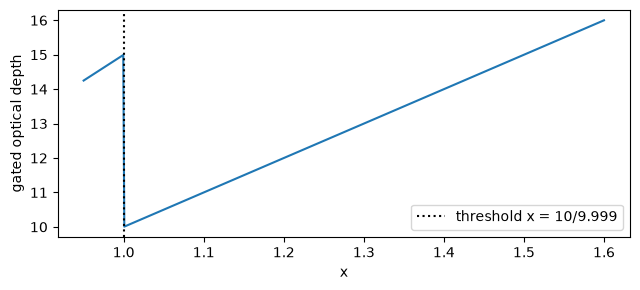


away from the kink (x = 1.5) autodiff is exact: +9.999000 = d/dx(9.999 x)


In [8]:
x = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
ad = torch.autograd.grad(proto.saturation_gate_torch(x), x)[0].item()
step = 1e-3
fd_gate = (
    proto.saturation_gate_np(1.0 + step) - proto.saturation_gate_np(1.0 - step)
) / (2 * step)
print(f"autodiff d/dx at x = 1.0 : {ad:+.4f}   <-- derivative of the branch taken")
print(f"central FD   at x = 1.0 : {fd_gate:+.4f}   <-- straddles the discontinuity")

xs = np.linspace(0.95, 1.6, 500)
ys = np.array([proto.saturation_gate_np(float(v)) for v in xs])
plt.figure(figsize=(6.5, 3))
plt.plot(xs, ys)
plt.axvline(10 / 9.999, ls=":", c="k", label="threshold x = 10/9.999")
plt.xlabel("x")
plt.ylabel("gated optical depth")
plt.legend()
plt.tight_layout()
plt.show()

far = torch.tensor(1.5, dtype=torch.float64, requires_grad=True)
print(
    "\naway from the kink (x = 1.5) autodiff is exact:",
    f"{torch.autograd.grad(proto.saturation_gate_torch(far), far)[0].item():+.6f}",
    "= d/dx(9.999 x)",
)

## 8. Is it worth it? The payoff verdict

Measured on this model (single forward: ~1.3 ms numpy, ~1.9 ms torch eager-GPU, ~0.8 ms
JAX-jit, all measured in section 9):

| situation | verdict |
| --- | --- |
| **n = 4 parameters, MAP fit only** | **Marginal.** ~3x cheaper per gradient and an order of magnitude fewer evaluations than Nelder-Mead, but finite differences are ten lines of code and also work. |
| **n = 20 parameters** (15 temperature knots + chemistry) | **Clear win.** The measured ratio grows linearly (2.8x at n = 4, 7.8x at n = 11, slope 0.99); at n = 20 finite differences need 40 forward passes per gradient against 2. |
| **Jacobian / Fisher matrix** | **Bigger win.** $2n$ forwards versus one backward pass, and $\sim n^2/2$ forwards for a Hessian. This is where error bars for large retrievals come from. |
| **Batched parameters / emulator training** | **Decisive.** 1024 spectra in ~28 ms with JAX `vmap` (~27 us each) versus ~2 s in a torch Python loop (~1.9 ms each) - section 9. |
| **HMC / NUTS sampling** | **Gradients are mandatory.** Thousands of steps, each wanting a gradient; nothing else gives you the posterior at that dimension. |
| **Emulator training, VI, design** | **Only possible with gradients** (gradient-matching losses, ELBO, Fisher-based design metrics). |
| **Memory** | **Cost, unmeasured here.** Reverse mode stores activations for every layer; the report's warning about the 100-layer loop is real. Section 12 proposes the measurement. |

**So:** if the goal were only a four-parameter MAP fit of a cheap forward model, the answer
would be "not worth it". The case for proceeding is that the ratio improves linearly with the
parameter count, and that gradients are the entry ticket to samplers, Fisher error bars,
batched inference and emulator training. Note also that the JAX win in this section is
partly *my* implementation work (the `E_2` below) rather than autodiff as such — which is
exactly the kind of cost the framework decision in section 9 has to weigh.

## 9. JAX or PyTorch: what the measurement says

Same model, same GPU, same batch, same measurement harness. The chart puts the two
frameworks side by side on four metrics, with the batched rows normalised *per spectrum* so
all of them are comparable. PyTorch has no bar for the last row because it cannot batch this
model at all.

The batch is 256 parameter sets, not more, because 1024 exhausts this 4 GB card during the
batched *gradient*: the reverse-mode tape of a 40-layer model is ~100 MB per saved
activation, so a few dozen of them do not fit. That is the report's memory caveat in
miniature, and it is the reason agenda item 3 (production-size memory) is ahead of any
framework decision.

Notable: JAX's single forward is now *faster* than torch's eager GPU forward because XLA
fuses the whole graph while torch launches one kernel per op. This is the opposite of the
impression from an earlier version of this notebook, where JAX looked slow — that was an
artefact of my own `E_2` workaround, not of JAX. Measure before deciding.

device: cuda, batch: 256 parameter sets

                                PyTorch         JAX
single forward                  1.89 ms     0.85 ms
single forward+backward         5.22 ms     1.66 ms
batched forward x256           550.4 ms    10.77 ms
batched gradient x256      not possible    22.26 ms
first call (compilation)           0 ms      761 ms

torch vmap              : RuntimeError: You tried to vmap over _Expn2, but it does not have vmap support. Please override and implement the vmap staticmethod or
per spectrum in a batch : torch 2150 us, jax 42 us


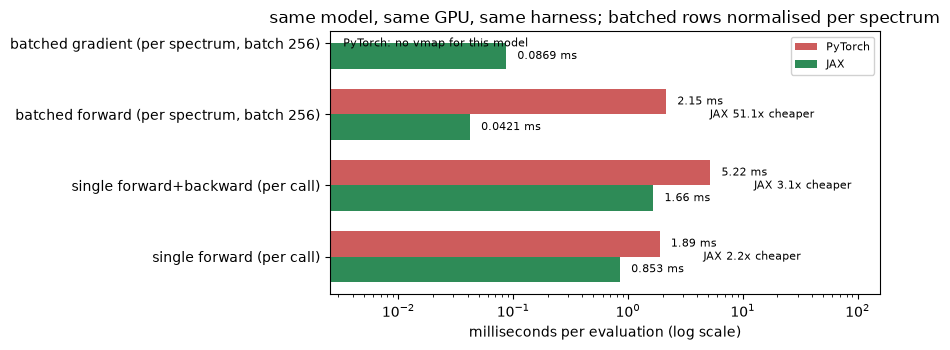

In [9]:
import gc

fw = proto.framework_report(batch_size=256, repeats=5)
gc.collect()
print(f"device: {fw['device']}, batch: {fw['batch_size']} parameter sets")
print()
print(f"{'':<26}{'PyTorch':>13}{'JAX':>12}")
print(
    f"{'single forward':<26}{fw['torch_forward_ms']:>10.2f} ms"
    f"{fw['jax_forward_ms']:>9.2f} ms"
)
print(
    f"{'single forward+backward':<26}{fw['torch_forward_backward_ms']:>10.2f} ms"
    f"{fw['jax_forward_grad_ms']:>9.2f} ms"
)
print(
    f"{'batched forward x' + str(fw['batch_size']):<26}"
    f"{fw['torch_loop_batch_ms']:>10.1f} ms{fw['jax_vmap_forward_ms']:>9.2f} ms"
)
print(
    f"{'batched gradient x' + str(fw['batch_size']):<26}{'not possible':>13}"
    f"{fw['jax_vmap_grad_ms']:>9.2f} ms"
)
print(
    f"{'first call (compilation)':<26}{'0':>10} ms"
    f"{fw['jax_forward_compile_ms']:>9.0f} ms"
)
print()
print(f"torch vmap              : {fw['torch_vmap_error']}")
print(
    f"per spectrum in a batch : torch {fw['torch_per_spectrum_us']:.0f} us,"
    f" jax {fw['jax_per_spectrum_us']:.0f} us"
)

metrics = [
    "single forward (per call)",
    "single forward+backward (per call)",
    "batched forward (per spectrum, batch 256)",
    "batched gradient (per spectrum, batch 256)",
]
torch_values = [
    fw["torch_forward_ms"],
    fw["torch_forward_backward_ms"],
    fw["torch_per_spectrum_us"] * 1e-3,
    np.nan,
]
jax_values = [
    fw["jax_forward_ms"],
    fw["jax_forward_grad_ms"],
    fw["jax_per_spectrum_us"] * 1e-3,
    fw["jax_vmap_grad_ms"] / fw["batch_size"],
]

positions = np.arange(len(metrics))
height = 0.36

fig, ax = plt.subplots(figsize=(9.0, 3.6))
torch_bars = ax.barh(
    positions + height / 2, torch_values, height, color="indianred", label="PyTorch"
)
jax_bars = ax.barh(
    positions - height / 2, jax_values, height, color="seagreen", label="JAX"
)

for bars in (torch_bars, jax_bars):
    for bar in bars:
        width = bar.get_width()
        if not np.isfinite(width):
            continue
        ax.text(
            width * 1.25,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.3g} ms",
            va="center",
            fontsize=8,
        )

for index, (torch_value, jax_value) in enumerate(zip(torch_values, jax_values)):
    if not np.isfinite(torch_value):
        ax.text(
            0.01,
            positions[index],
            "  PyTorch: no vmap for this model",
            va="center",
            fontsize=8,
            transform=ax.get_yaxis_transform(),
        )
        continue
    ax.text(
        max(torch_value, jax_value) * 2.4,
        positions[index],
        f"JAX {torch_value / jax_value:.1f}x cheaper",
        va="center",
        fontsize=8,
    )

finite = [v for v in torch_values + jax_values if np.isfinite(v) and v > 0]
ax.set_xlim(min(finite) * 0.06, max(finite) * 30)
ax.set_yticks(positions)
ax.set_yticklabels(metrics)
ax.set_xscale("log")
ax.set_xlabel("milliseconds per evaluation (log scale)")
ax.set_title("same model, same GPU, same harness; batched rows normalised per spectrum")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

### 9b. The rest of the picture: what each framework demands of this codebase

The numbers above favour JAX for batched work and it is now competitive per call. The
non-numerical columns are where PyTorch wins, and they are the reason the report's §6
recommends prototyping in PyTorch first.

| dimension | PyTorch | JAX | evidence |
| --- | --- | --- | --- |
| fit with the existing OOP / `@fitparam` design | **keeps working** (eager, mutation fine) | must become pure functions + an explicit PyTree | report §5.1, §6.1 |
| layer loop in `path_integral` | works as-is, 133 ms vs 3.4 ms batched | needs `lax.fori_loop`/`vmap` — and then it is fast (1.3 ms) | prototype |
| `if tau[layer].min() > 10` | works, silently non-smooth | Python `if` on a traced value raises under `jit`; plain `grad` silently picks a branch | measured |
| `scipy.special.expn` (Guillot) | custom `autograd.Function`, `gradcheck` passes, 0 ms overhead (host scipy) | JAX's own `expn` is unusable (74 s); needed a hand-written series + continued fraction (1.5e-14, 0.3 ms) | prototype |
| batching (`vmap`) | blocked by the host-scipy `E_2` unless rewritten in torch ops | works today, 41x faster than a torch loop | measured |
| first-call latency | ~0 (eager); shapes are free | ~0.6 s per shape for the forward, 1.1 s for the gradient | measured |
| global caches (`GlobalCache`, `OpacityCache`) | tolerable, but fragile | breaks tracing; must be threaded through explicitly | report §4.1 |
| stochastic / data-dependent control | dynamic graph handles it | requires `lax.cond`/masks | report §4.2 |
| ecosystem for the payoff | `torch.optim.LBFGS` today; Pyro, Hamiltorch for HMC | `grad`/`jit`/`vmap`/`hessian` compose; NumPyro, BlackJAX for HMC | report §3 |
| incremental adoption | **yes** — one contribution at a time behind a flag | no — purity has to hold everywhere at once | report §7.1 |
| effort to first working `dchi2/dtheta` | low-medium (mechanical numpy -> torch) | high (functional rewrite of ~15-20 files) | report §5.4/§6.4 |

**One caveat on that batching number.** The reason torch cannot batch is *our* `E_2`
(host scipy inside the primal), not torch. Rewriting it in torch ops, as the JAX one is
written in jnp ops, would enable `torch.vmap`. Even then the measured per-call gap (~1.9 ms
vs ~0.8 ms) suggests torch stays roughly 2x behind per call for this kernel count, because
XLA fuses the graph while torch dispatches one kernel per operation. Treat the ~70x batched
ratio as an upper bound on the framework difference and the ~2x per-call ratio as the
floor - but do not plan batched torch work until a torch-native `E_2` exists.

**Recommendation for discussion.** Take the PyTorch route for the *first* end-to-end
differentiable path, because (a) it can be adopted one contribution at a time behind the
existing `@fitparam` API, so the rest of the codebase keeps working while the port happens,
(b) it reaches the two immediate deliverables - MAP fits and Fisher/Laplace error bars -
with the least new infrastructure, and (c) the JAX advantages measured here pay off mainly
for batched or sampled workloads, which are later goals. Choose JAX instead if the team
already knows that batched emulator training or HMC at 20+ parameters is the primary
target: the measured batched ratio is not something PyTorch recovers without also rewriting
the special functions in torch ops, and JAX is now ahead per call as well. A hybrid is
viable and common in astronomy: JAX for the differentiable core, PyTorch for anything
neural.

**What would change this recommendation:** (1) a production-size memory measurement showing
reverse mode cannot hold 100 layers x 10^4 points; (2) the HMC smoke test showing nested
sampling is already good enough at the target dimension; (3) a torch-native `E_2` closing the
batching gap; (4) `torch.compile` fusing the eager graph well enough to close the per-call
gap.

## 10. What has to change in the real codebase

A file-by-file inventory, mapping each obstacle in the report to the module that has to
change and the framework-specific consequence. This is the work estimate, not the plan.

| where | today | change needed | framework note |
| --- | --- | --- | --- |
| `data/fittable.py`, `optimizer/optimizer.py` | `@fitparam` getters/setters mutate Python floats; `FitParam.fit_value` does `math.log10` | keep the metadata, add a tensor-valued store; `log10` -> framework op | torch: setters keep working; JAX: parameters become a PyTree passed to pure functions |
| `model/transmission.py::path_integral` | `for layer` loop, in-place `tau[layer] += ...`, `if tau[layer].min() > 10: continue` | vectorise the layer loop; freeze or smooth the early-out | torch: loop works but is 40x slower than the batched form; JAX: traced `if` forbids it |
| `model/transmission.py::compute_absorption` | `np.exp(-tau, out=tau)` | out-of-place `exp` | both: in-place blocks autograd |
| `contributions/contribution.py`, `absorption.py`, `cia.py` | numba `nopython` kernels + `np.einsum` | keep numba for the value-only path; add tensor kernels for the AD path | both: numba rejects tensors (measured) |
| `opacity/interpolateopacity.py` | `find_closest_pair` searchsorted index lookup | keep indices integer, detach them, interpolate with weights | both: validated in the prototype |
| `opacity/ktables/ktable.py`, `data/profiles/temperature/temparray.py` | `scipy.interpolate.interp1d` | framework-native linear interpolation | JAX has `jnp.interp`; torch needs a gather-based equivalent |
| `data/profiles/temperature/guillot.py` | `scipy.special.expn` | torch: custom `autograd.Function` (done here); JAX: hand-written bounded `E_2` (done here) | the JAX route is a genuine, measured cost |
| `optimizer/optimizer.py::chisq_trans` | `try/except InvalidModelException -> np.nan` | return an explicit large loss (`inf`) plus a validity flag | both: `nan` has undefined gradient |
| `binning/` | bin summing (searchsorted) | segment-sum style reduction | both feasible |
| `cache/`, `GlobalCache`, `OpacityCache`, `plugins/` | global mutable registries | must be bypassed on the differentiable path | JAX: breaks tracing outright |
| `util/math.py`, `util/math_numba.py` | numba `interp_lin`/`interp_exp`/`intepr_bilin` | mirror in framework ops | both |

Two structural decisions sit underneath this table and block everything else:

* **Where do fitting parameters live?** A tensor store behind `@fitparam` (torch) or a PyTree
  with pure profile functions (JAX). Every profile, contribution and the optimizer touch this.
* **Does the numba path stay?** Keeping it means dual maintenance but zero regression risk for
  existing retrievals; replacing it means one code path and one performance story.

## 11. Open questions and a proposed agenda

What this notebook has *not* answered, ordered so that each item de-risks the next. Each has a
success criterion, so the experiments can be judged rather than argued about.

1. **Parameter representation** (blocking). Decide tensor store vs PyTree. *Success:* one
   profile class ported both ways, and the diff readable by the team.
2. **One real contribution, end to end.** Port H2O (k-table) plus CIA to the chosen framework
   behind a flag, with a real opacity file. *Success:* `dchi2/dtheta` matches finite
   differences to 1e-5, and the differentiable path is within 2x of the numba path.
3. **Production-size memory.** 100 layers, 10^4 wavenumbers, 5 contributions, measured peak
   GPU memory in the backward pass. *Success:* fits the target GPU with the layer loop
   vectorised; otherwise evaluate gradient checkpointing. (The prototype's 40x300 grid is too
   small to say anything.)
4. **HMC smoke test.** NUTS on one real 6-parameter retrieval against the current nested
   sampling on the same data. *Success:* consistent posterior within errors, less wall-clock.
5. **Dual-path decision.** Keep numba for value-only production, or replace it. *Success:*
   a benchmark of both paths on the same retrieval.
6. **Framework choice** — this notebook's section 9, revisited after items 2-4. *Trigger to
   re-measure:* if batched emulator training or HMC at 20+ parameters enters scope, re-run
   `framework_report()` with the real model; JAX's batching advantage is its strongest card.
7. **Not measured at all here:** k-tables/CIA/clouds, `torch.compile`, MPI interplay,
   output/plotting paths, priors and model-selection machinery, and the 2-5x forward
   overhead the report predicts for a naive differentiable path.

## 12. Cost of the pieces

The underlying forward and backward cost, including the per-layer loop that vectorisation is
meant to remove, and the `E_2` special function that each framework needs (torch: scipy in a
custom rule; JAX: hand-written series + continued fraction).

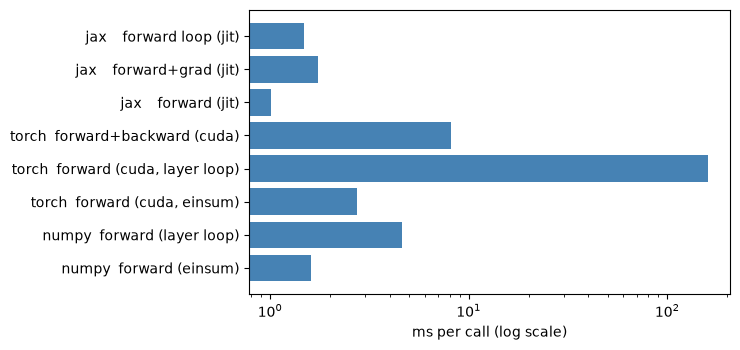

numpy  forward (einsum)                 1.613 ms
numpy  forward (layer loop)             4.632 ms
torch  forward (cuda, einsum)           2.741 ms
torch  forward (cuda, layer loop)     160.393 ms
torch  forward+backward (cuda)          8.148 ms
jax    forward (jit)                    1.007 ms
jax    forward+grad (jit)               1.734 ms
jax    forward loop (jit)               1.478 ms


In [10]:
results = proto.benchmark(repeats=10)
labels = [label for label, _ in results]
millis = [ms for _, ms in results]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(labels, millis, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("ms per call (log scale)")
fig.tight_layout()
plt.show()

for label, ms in results:
    print(f"{label:<36} {ms:8.3f} ms")

## 13. Summary for the discussion

* **Feasibility: yes.** A faithful port of the forward model reproduces the numpy reference,
  and its autodiff gradients match central differences in both PyTorch and JAX. Every
  structural obstacle in the report has a demonstrated fix, and the prototype implements all
  of them: detached `searchsorted` indices, a bounded `E_2`, no in-place `exp`, vectorised
  layer accumulation.
* **Worth: not for small retrievals.** The measured gain is ~2.8x in gradient cost at
  n = 4 and grows linearly with the parameter count (7.8x at n = 11, slope 0.99). The
  compelling cases are large-n retrievals, Fisher/Laplace error bars, batched inference and
  HMC — not four-parameter MAP fits.
* **Framework: PyTorch first, on the evidence - but the margin is not what it looked like.**
  JAX is now ahead per call (~0.8 ms vs ~1.9 ms) and far ahead batched (1024 spectra:
  ~28 ms vs ~2 s), yet it demands a purity rewrite and hand-written special functions, of
  which the `E_2` above is one measured example. PyTorch alone can be adopted incrementally,
  which is why it is the safer first step; revisit after the real-model spike in section 11,
  and note that a torch-native `E_2` would remove the `vmap` blocker.
* **Two things to decide before writing code:** where fitting parameters live (tensor store vs
  PyTree), and whether the numba path stays alongside the differentiable one.
* **One thing not to port literally:** the early-out in `path_integral` is discontinuous, so
  its gradient is quietly wrong at the saturation threshold. Freeze the decision on an
  untraced value or replace it with a smooth mask.